<a href="https://colab.research.google.com/github/LucioFassarella/SSD---Simulacoes-de-Sistemas-Dissipativos/blob/main/SQSD_Modelo_qubit_amplitude_amortecida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="red"><b>Simulação Quântica de Sistemas Dissipativos</b></font>

<div align="center"><font color="magenta"><b>Qubit com amortecimento de AMPLITUDE</b></font></div>
<!--
<center><img align = "center" src="https://drive.google.com/uc?export=view&id=1usXrPscUXzfQF5wNtkvuVGARuuhcgyw-" alt="grafo" width="500"></center>

<center>"You never understand things. You just get used to them." (John von Neumann)</center>
-->

---
**Referências**

*   Daniel A. Lidar: *Lecture Notes on the Theory of Open Quantum Systems*. URL:
[https://arxiv.org/abs/1902.00967](https://arxiv.org/abs/1902.00967).
    *   (Lindbladian -> Kraus Operators: pp.47-48)
*   Pirandola, Stefano *et al.*: *Minimal qudit code for a qubit in the phase-damping channel*. Physical Review A 77, 032309 (2008).

*   Kline, S.J.: *Amplitude Damping vs Phase Damping in Quantum Computing: Key Differences and Impacts on Qubit Fidelity*. URL: [https://techiny.com/quantum-computing/amplitude-damping-vs-phase-damping](https://techiny.com/quantum-computing/amplitude-damping-vs-phase-damping).

*   Bohrium: *Amplitude Damping and Phase Damping Channels*. URL: [https://www.bohrium.com/en/sciencepedia/feynman/quantum_information_quantum_computation-amplitude_da

Qiskit
*   [Método qiskit.quantum_info.Choi](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Choi)



**Espaço de Hilbert e equação de Lindblad**:
$$
\mathcal{H} = \mathcal{Q}_1
$$
$$
\frac{d}{dt}\rho =\gamma\left(\sigma^+\rho \sigma^- - \frac{1}{2}\{\sigma^-\sigma^+,\rho\}\right),
$$
onde
$$
\sigma^+ := \vert0\rangle\langle 1 \vert,\ \sigma^-  :=\vert 1\rangle\langle 0 \vert.
$$
**Hamiltoniano e operador de Lindblad**:
$$
H =  \omega Z
$$
$$
\begin{split}
L_1 &:= \sigma^+,\\
L_0 &:= - \frac{\gamma}{2} L_1^\dagger L_1 - i\omega Z = - \frac{\gamma}{2}\vert 1\rangle\langle 1 \vert - i\omega Z.
\end{split}
$$
Operadores de Kraus infinitezimais com operador residual $R$:
$$
\begin{split}
K_0 &= I -\left(\frac{\gamma}{2}\vert 1\rangle\langle 1 \vert + i\omega Z\right) dt + Rdt^2,\\
K_1 &= \sqrt{\gamma dt}\sigma^+.
\end{split}
$$
Equação residual:
$$
	\begin{split}
		\frac{\gamma^2}{4}\vert 1\rangle\langle 1 \vert + \omega^2I + R + R^\dagger - \frac{\gamma}{2}( \vert 1\rangle\langle 1 \vert R + R^\dagger \vert 1\rangle\langle 1 \vert - i\omega ZR^\dagger + i\omega R Z )dt + R^\dagger R dt^2 = 0.
	\end{split}
$$

Com o ansatz
$$
R = a \vert 0\rangle\langle 0 \vert + b \vert 1\rangle\langle 1 \vert\ \ (a,b \in \mathbb{R})
$$
a equação residual é reduzida um par de equações quadráticas para $a$ e $b$, cujas soluções obtemos explicitamente:
$$
\frac{\gamma^2}{4}\vert 1\rangle\langle 1 \vert + \omega^2 \vert 0\rangle\langle 0 \vert + \omega^2\vert 1\rangle\langle 1 \vert + 2a \vert 0\rangle\langle 0 \vert + 2b\vert 1\rangle\langle 1 \vert - \gamma b dt \vert 1\rangle\langle 1 \vert + dt^2a^2\vert 0\rangle\langle 0 \vert + dt^2b^2\vert 1\rangle\langle 1 \vert = 0
$$
...
$$
\iff \left(\omega^2  + 2a + dt^2a^2 \right) \vert 0\rangle\langle 0 \vert +
\left(\frac{\gamma^2}{4} + \omega^2 + 2b - \gamma dt b + dt^2b^2\right)\vert 1\rangle\langle 1 \vert= 0
$$
...
$$
\iff \left\lbrace
\begin{array}{l}
\omega^2  + 2a + dt^2a^2 = 0 \\
\frac{\gamma^2}{4} + \omega^2 + (2 - \gamma dt) b + dt^2b^2 = 0
\end{array}
\right.
$$
Soluções:
$$
a = - \frac{1 - \sqrt{1- \omega^2dt^2}}{dt^2} = - \frac{1}{2}\omega^2 + O(dt^2)
$$
e
$$
b  = - \frac{1 - \gamma dt/2 - \sqrt{1- \gamma dt - \omega^2 dt^2}}{dt^2} = - \left( \frac{\omega^2}{2} + \frac{\gamma^2}{8} \right) + O(dt^2).
$$

**Isometria de Stinespring**

$$
\begin{split}
\mathcal{V} &= \mathrm{spam}\left\{K_0\vert 0\rangle\otimes\vert0\rangle + K_1\vert 0\rangle\otimes\vert1\rangle,\ %
K_0\vert 1\rangle\otimes\vert0\rangle + K_1\vert 1\rangle\otimes\vert1\rangle \right\}\\
&=\mathrm{spam}\left\{\kappa_{0}\vert 0\rangle\otimes\vert0\rangle,\ %
\kappa_{1} \vert 1\rangle\otimes\vert 0\rangle + \kappa_{2}\vert 0\rangle\otimes\vert 1\rangle \right\},
\end{split}
$$
onde
$$
\begin{split}
\kappa_{0} &:= 1 + adt^2 - i\omega dt\\
\kappa_{1} &:= 1 - \gamma dt/2  + bdt^2 + i\omega dt\\
\kappa_{2} &:= \sqrt{\gamma dt}.
\end{split}
$$

**Unitário de Stinespring**

Base ortonormal de $\mathcal{V}$:
$$
\begin{split}
\vert\phi_{00}\rangle &:= \kappa_{0}\vert 0\rangle\otimes\vert 0\rangle \\
\vert\phi_{01}\rangle &:= +\kappa_{1} \vert 1\rangle\otimes\vert 0\rangle + \kappa_{2}\vert 0\rangle\otimes\vert 1\rangle
\end{split}
$$

Base ortonormal de $\mathcal{V}^\perp$:
$$
\begin{split}
\vert\phi_{10}\rangle &:=- \kappa_{2} \vert 1\rangle\otimes\vert 0\rangle + \kappa_{1}\vert 0\rangle\otimes\vert 1\rangle\\
\vert\phi_{11}\rangle &:= \kappa_{0}\vert 1\rangle\otimes\vert 1\rangle
\end{split}
$$
Unitário de Stinespring:
$$
\begin{split}
W \ \ \vert j\rangle\otimes\vert k\rangle \mapsto \vert \phi_{jk}\rangle,\ \ j,k=0,1.
\end{split}
$$


## QISKIT: Carregamento

In [1]:
!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib
!pip install pylatexenc

import qiskit
qiskit.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 19.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.

'2.5.1'

In [2]:
'''
from qiskit_ibm_runtime import QiskitRuntimeService

# Conecção com a IBM

token_privado = "" # <-- Inserir token privado na IBM
instance_do_projeto = "" # <-- Inserir instance do projeto

from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token = token_privado,
    instance = instance_do_projeto
    )

## Save account to disk and save it as the default.
#QiskitRuntimeService.save_account(channel="ibm_cloud", token="<IBM Cloud API key>", instance="<IBM Cloud CRN>", name="account-name", set_as_default=True)

## Load the saved credentials
#service = QiskitRuntimeService(name="account-name")
'''

'\nfrom qiskit_ibm_runtime import QiskitRuntimeService\n\n# Conecção com a IBM\n\ntoken_privado = "" # <-- Inserir token privado na IBM\ninstance_do_projeto = "" # <-- Inserir instance do projeto\n\nfrom qiskit_ibm_runtime import QiskitRuntimeService\nservice = QiskitRuntimeService(\n    channel="ibm_cloud",\n    token = token_privado,\n    instance = instance_do_projeto\n    )\n\n## Save account to disk and save it as the default.\n#QiskitRuntimeService.save_account(channel="ibm_cloud", token="<IBM Cloud API key>", instance="<IBM Cloud CRN>", name="account-name", set_as_default=True)\n\n## Load the saved credentials\n#service = QiskitRuntimeService(name="account-name")\n'

In [3]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city

# Modelagem

In [4]:
"PARÂMETROS DO SISTEMA e da SIMULAÇÃO"

import numpy as np

# Parâmetros do sistema

w = 1.2 # Hamiltoniano
print(f"Parâmetro do Hamiltoniano: w = {w}")

g = 0.1 # taxa de dissipação
print(f"Taxa de dissipação: g = {g}")

# Parâmetros da simulação

tempo = 1 # duração da simulação
print(f"Tempo de simulação: tempo = {tempo}")

num_steps = 10 # número de passos da simulação
print(f"Número de passos da simulação: num_steps = {num_steps}")

dt = tempo/num_steps # step_size = magnitude de ada passo da simulação
print(f"Magnitude dos passos da simulação: dt = {dt}")

# Coeficientes

a = - (1 - np.sqrt(1 - (w**2)*(dt**2)))/(dt**2)

b = - (1 - g*dt/2 - np.sqrt(1 - g*dt - (w**2)*(dt**2)))/dt**2

print(f"Coeficiente a: a = {a}")
print(f"Coeficiente b: b = {b}")

k0 = 1 + a*dt**2 - 1j*w*dt
k1 = 1 - g*dt/2 + b*dt**2 + 1j*w*dt
k2 = np.sqrt(g*dt)

print(f"Coeficiente k0: k0 = {k0}")
print(f"Coeficiente k1: k1 = {k1}")
print(f"Coeficiente k2: k2 = {k2}")

W = np.array([
    [k0, 0, 0, 0],
    [0, k1, k2, 0],
    [0, -k2, k1, 0],
    [0, 0, 0, k0]
    ])

print(f"Unitário de Stinespring: W = \n{W}")

# Verificação de unitariedade

print(f"W @ W.conj().T = \n{np.dot(W, W.conj().T)}")

Parâmetro do Hamiltoniano: w = 1.2
Taxa de dissipação: g = 0.1
Tempo de simulação: tempo = 1
Número de passos da simulação: num_steps = 10
Magnitude dos passos da simulação: dt = 0.1
Coeficiente a: a = -0.7226108320731449
Coeficiente b: b = -0.7275342010740314
Coeficiente k0: k0 = (0.9927738916792685-0.12j)
Coeficiente k1: k1 = (0.9877246579892597+0.12j)
Coeficiente k2: k2 = 0.1
Unitário de Stinespring: W = 
[[ 0.99277389-0.12j  0.        +0.j    0.        +0.j    0.        +0.j  ]
 [ 0.        +0.j    0.98772466+0.12j  0.1       +0.j    0.        +0.j  ]
 [ 0.        +0.j   -0.1       +0.j    0.98772466+0.12j  0.        +0.j  ]
 [ 0.        +0.j    0.        +0.j    0.        +0.j    0.99277389-0.12j]]
W @ W.conj().T = 
[[1.00000000e+00+0.j    0.00000000e+00+0.j    0.00000000e+00+0.j
  0.00000000e+00+0.j   ]
 [0.00000000e+00+0.j    1.00000000e+00+0.j    2.70741572e-18-0.024j
  0.00000000e+00+0.j   ]
 [0.00000000e+00+0.j    2.70741572e-18+0.024j 1.00000000e+00+0.j
  0.00000000e+00+0.j 

In [6]:
"HAMILTONIANO e PORTA W"

# Hamiltoniano
from qiskit.quantum_info import SparsePauliOp

num_qubts = 1 + num_steps

Hamiltoniano = SparsePauliOp.from_sparse_list([("Z", [0], w)], num_qubits= num_qubts) # Hamiltoniano

# Porta W

from qiskit.circuit.library import UnitaryGate

W_gate = UnitaryGate(W, check_input = False, label="W")

In [9]:
"CIRCUITO QUÂNTICO DA SIMULAÇÃO"

num_qubts = 1 + num_steps # número de qubits do circuito quântico

qbt_system = QuantumRegister(1)  # registro quântico do sistema
qbt_clock = [QuantumRegister(1) for step in range(num_steps)] # registros para evolução temporal

cbt_system = ClassicalRegister(1) # registro clássico do sistema
cbt_clock = [ClassicalRegister(1) for step in range(num_steps)] # registros para medição temporal

qcirc = QuantumCircuit(qbt_system, *qbt_clock, cbt_system, *cbt_clock) # circuito quântico da simulação

#qc_simulacao.draw()

"ESTADO INICIAL"

qcirc.x(qbt_system[0])

"EVOLUÇÃO"

for step in range(num_steps):
    qcirc.append(W_gate, [qbt_system[0], qbt_clock[step][0]])
    qcirc.barrier()

qcirc.draw('mpl')

qcirc.draw()

┌───┐┌────┐ ░ ┌────┐ ░ ┌────┐ ░ ┌────┐ ░ ┌────┐ ░ ┌────┐ ░ ┌────┐ ░ »
  q22: ┤ X ├┤0   ├─░─┤0   ├─░─┤0   ├─░─┤0   ├─░─┤0   ├─░─┤0   ├─░─┤0   ├─░─»
       └───┘│  W │ ░ │    │ ░ │    │ ░ │    │ ░ │    │ ░ │    │ ░ │    │ ░ »
  q23: ─────┤1   ├─░─┤  W ├─░─┤    ├─░─┤    ├─░─┤    ├─░─┤    ├─░─┤    ├─░─»
            └────┘ ░ │    │ ░ │  W │ ░ │    │ ░ │    │ ░ │    │ ░ │    │ ░ »
  q24: ────────────░─┤1   ├─░─┤    ├─░─┤  W ├─░─┤    ├─░─┤    ├─░─┤    ├─░─»
                   ░ └────┘ ░ │    │ ░ │    │ ░ │  W │ ░ │    │ ░ │    │ ░ »
  q25: ────────────░────────░─┤1   ├─░─┤    ├─░─┤    ├─░─┤  W ├─░─┤    ├─░─»
                   ░        ░ └────┘ ░ │    │ ░ │    │ ░ │    │ ░ │  W │ ░ »
  q26: ────────────░────────░────────░─┤1   ├─░─┤    ├─░─┤    ├─░─┤    ├─░─»
                   ░        ░        ░ └────┘ ░ │    │ ░ │    │ ░ │    │ ░ »
  q27: ────────────░────────░────────░────────░─┤1   ├─░─┤    ├─░─┤    ├─░─»
                   ░        ░        ░        ░ └────┘ ░ │    │ ░ │    │ ░ »
  q28: ────────────░────────░────────░────────░────────░─┤1   ├─░─┤    ├─░─»
                   ░        ░        ░        ░        ░ └────┘ ░ │    │ ░ »
  q29: ────────────░────────░────────░────────░────────░────────░─┤1   ├─░─»
                   ░        ░        ░        ░        ░        ░ └────┘ ░ »
  q30: ────────────░────────░────────░────────░────────░────────░────────░─»
                   ░        ░        ░        ░        ░        ░        ░ »
  q31: ────────────░────────░────────░────────░────────░────────░────────░─»
                   ░        ░        ░        ░        ░        ░        ░ »
  q32: ────────────░────────░────────░────────░────────░────────░────────░─»
                   ░        ░        ░        ░        ░        ░        ░ »
c22: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c23: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c24: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c25: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c26: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c27: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c28: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c29: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c30: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c31: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
c32: 1/════════════════════════════════════════════════════════════════════»
                                                                           »
«       ┌────┐ ░ ┌────┐ ░ ┌────┐ ░ 
«  q22: ┤0   ├─░─┤0   ├─░─┤0   ├─░─
«       │    │ ░ │    │ ░ │    │ ░ 
«  q23: ┤    ├─░─┤    ├─░─┤    ├─░─
«       │    │ ░ │    │ ░ │    │ ░ 
«  q24: ┤    ├─░─┤    ├─░─┤    ├─░─
«       │    │ ░ │    │ ░ │    │ ░ 
«  q25: ┤    ├─░─┤    ├─░─┤    ├─░─
«       │    │ ░ │    │ ░ │    │ ░ 
«  q26: ┤  W ├─░─┤    ├─░─┤    ├─░─
«       │    │ ░ │  W │ ░ │    │ ░ 
«  q27: ┤    ├─░─┤    ├─░─┤  W ├─░─
«       │    │ ░ │    │ ░ │    │ ░ 
«  q28: ┤    ├─░─┤    ├─░─┤    ├─░─
«       │    │ ░ │    │ ░ │    │ ░ 
« 

In [ ]:
"EXPERIMENTOS"


In [10]:
from qiskit.quantum_info import Statevector

vetor_estado = Statevector(qcirc)

vetor_estado.draw('latex')

<IPython.core.display.Latex object>

In [11]:
from qiskit_aer.primitives import Estimator as AerEstimator

# Remoção de medidas no circuito para executar o AerEstimator
qcirc_simulacao = qcirc.remove_final_measurements(inplace=False)

# Inicialização do Estimator
estimator = AerEstimator()

# Execução dos experimentos
job = estimator.run(qcirc_simulacao, Hamiltoniano)
result = job.result()

# Extração do valor esperado do Hamiltoniano
expectation_value = result.values[0]

print(f"<H>: {expectation_value}")

<H>: -0.975


## Modelo*:
$$
\begin{split}
w &= 0,\\
\gamma &= 1.52 \times 10^9/s^{-1}.
\end{split}
$$
Equação de Lindblad:
$$
\frac{d\rho}{dt} = \gamma \left\lbrack\sigma^+\rho\sigma^- - \frac{1}{2}\left\{\sigma^-\sigma^+,\rho\right\}\right\rbrack
$$
Solução exata:
$$
\rho(t) = M_0(t)\rho(0)M_0(t) + M_1(t)\rho(0)M_1(t),
$$
onde
$$
\begin{split}
	M_0(t) &= \frac{1+\sqrt{e^{-\gamma t}}}{2}I + \frac{1-\sqrt{e^{-\gamma t}}}{2}\sigma_z = %
\begin{pmatrix}
1 & 0\\
0 & \sqrt{e^{-\gamma t}}
\end{pmatrix},\\
	M_1(t) &= \sqrt{1- e^{-\gamma t}}\sigma^+ = %
\begin{pmatrix}
0 & \sqrt{1 - e^{-\gamma t}}\\
0 & 0
\end{pmatrix}.
\end{split}
$$
Evolução para condições iniciais específicas.

### $\rho(0) = \vert 0 \rangle \langle 0 \vert $
$$
\begin{split}
\rho(0) &= \vert 0 \rangle \langle 0 \vert = %
\begin{pmatrix}
1 & 0\\
0 & 0
\end{pmatrix}
\\
\leadsto \rho(t) &= \begin{pmatrix}
1 & 0\\
0 & 0
\end{pmatrix}\ \ \text{(constante)}
\end{split}
$$
### $\rho(0) = \vert 1 \rangle \langle 1 \vert $
$$
\begin{split}
\rho(0) &= \vert 1 \rangle \langle 1 \vert = %
\begin{pmatrix}
0 & 0\\
0 & 1
\end{pmatrix}
\\
\leadsto \rho(t) &=  (1 - e^{-\gamma t})\vert 0 \rangle \langle 0\vert + e^{-\gamma t}\vert 1 \rangle \langle 1\vert = \begin{pmatrix}
1 - e^{-\gamma t} & 0\\
0 & e^{-\gamma t}
\end{pmatrix}
\end{split}
$$
### $\rho(0) = \frac{1}{2}\left(\frac{\vert 0 \rangle + \vert 1 \rangle}{\sqrt{2}}\right)\left(\frac{\langle 0 \vert + \langle 1 \vert}{\sqrt{2}} \right) + \frac{1}{2}\vert 1 \rangle \langle 1 \vert$

$$
\rho(0) = \frac{1}{4} \begin{pmatrix}
1 & 1\\
1 & 3
\end{pmatrix}.
$$
$$
\leadsto \rho(t) = \frac{1}{4} \begin{pmatrix}
4 - 3e^{-\gamma t} & \sqrt{e^{-\gamma t}}\\
\sqrt{e^{-\gamma t}} & 3e^{-\gamma t}
\end{pmatrix}.
$$

In [12]:
import numpy as np

g = 1.52e9

def a(t):
    1 - np.exp(-g*t)

def b(t):
    np.exp(-g*t)

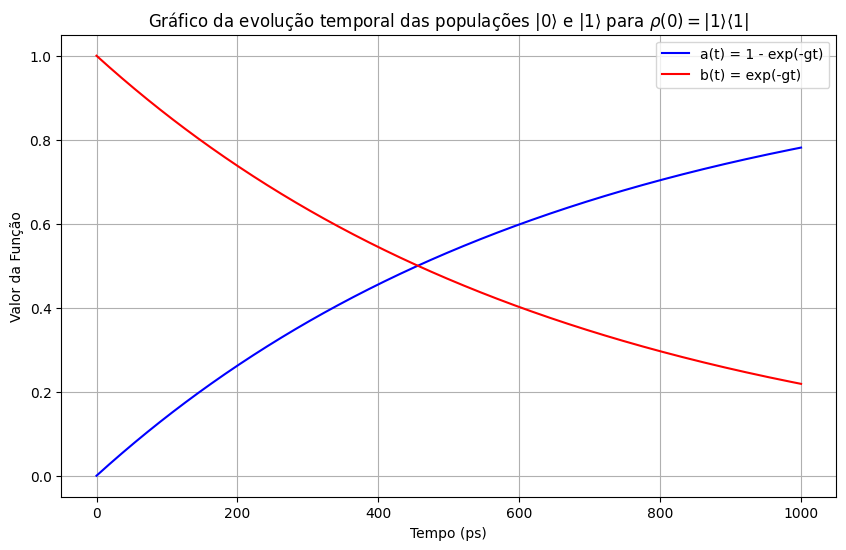

In [20]:
import matplotlib.pyplot as plt

# Time range in picoseconds
t_ps = np.linspace(0, 1000, 500) # 0 to 1000 ps with 500 points

# Convert time to seconds for calculations (g is in s^-1)
t_s = t_ps * 1e-12

# Redefine a and b functions locally to use the global g from previous cell
def a_func(t):
    return 1 - np.exp(-g * t)

def b_func(t):
    return np.exp(-g * t)

# Calculate function values
a_values = a_func(t_s)
b_values = b_func(t_s)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_ps, a_values, label= r'a(t) = 1 - exp(-gt)', color = 'blue')
plt.plot(t_ps, b_values, label= r'b(t) = exp(-gt)', color = 'red')
plt.xlabel('Tempo (ps)')
plt.ylabel('Valor da Função')
plt.title(r'Gráfico da evolução temporal das populações $\vert 0 \rangle$ e $\vert 1 \rangle$ para $\rho(0) = \vert 1 \rangle\langle 1 \vert$')
plt.legend()
plt.grid(True)
plt.show()